In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

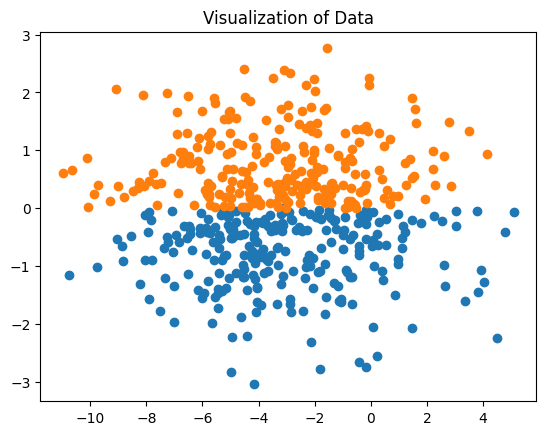

In [ ]:
def gen_gaussian_points(n, mean, sigma):
    return np.random.normal(mean, sigma, [n, 2])

N = 500

X = gen_gaussian_points(N, [-3, 0], [3, 1])
y = (X[:,1]>0).astype(float)
y = np.expand_dims(y, axis=-1)


plt.scatter(*X[y.squeeze()==0].T)
plt.scatter(*X[y.squeeze()==1].T)
plt.title("Visualization of Data")
plt.show()

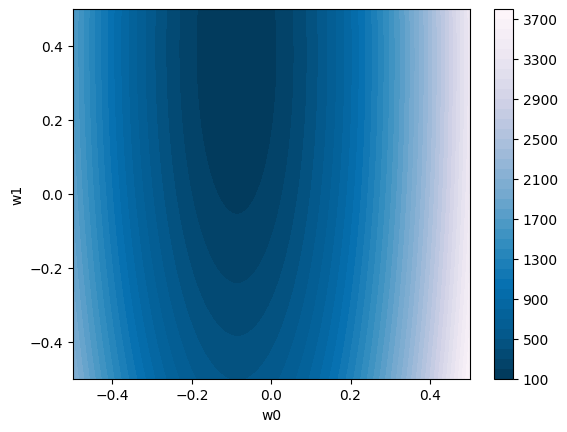

In [ ]:
w0_s, w1_s = np.meshgrid(np.linspace(-0.5, 0.5, 100), np.linspace(-0.5, 0.5, 100))
w_s = np.stack([w0_s.reshape(-1), w1_s.reshape(-1)], axis=1)
loss_s = ((X @ w_s.T - y) ** 2).sum(axis=0).reshape(100, 100)
from matplotlib import ticker, cm
plt.contourf(w0_s, w1_s, loss_s, cmap=cm.PuBu_r, levels=40)
plt.colorbar()
plt.xlabel("w0")
plt.ylabel("w1")
plt.show()

In [ ]:
def runGD(maxiter,stepsize):
    w = np.zeros((2, 1))
    grads = []
    ws = []
    losses = []
    for i in range(maxiter):
        grad = 2 * (X.T @ X @ w) - 2 * X.T @ y
        w = w - stepsize * grad
        grads.append(grad)
        ws.append(w)
        loss = np.linalg.norm(y - X @ w) ** 2
        losses.append(loss)
    print("Final loss =", loss)
    grads = np.array(grads).squeeze()
    ws = np.array(ws).squeeze()
    return grads, ws, losses

maxiter = 100
stepsize = 1e-4
grads, ws, losses = runGD(maxiter,stepsize)

Final loss = 102.75171092495734


In [ ]:
def runGDM(maxiter, stepsize, beta):
    w = np.zeros((2, 1))
    grads_m = []
    ws_m = []
    losses_m = []
    for i in range(maxiter):
        grad = 2 * (X.T @ X @ w) - 2 * X.T @ y
        if i == 0:
            smoothed_grad = grad
        else:
            smoothed_grad = beta * smoothed_grad + (1 - beta) * grad
        w = w - stepsize * smoothed_grad
        grads_m.append(grad)
        ws_m.append(w)
        loss = np.linalg.norm(y - X @ w) ** 2
        losses_m.append(loss)
    print("Final loss =", loss)
    grads_m = np.array(grads_m).squeeze()
    ws_m = np.array(ws_m).squeeze()
    return grads_m, ws_m, losses_m


maxiter = 100
stepsize = 1e-4
beta = 0.6
grads_m, ws_m, losses_m = runGDM(maxiter, stepsize, beta)


Final loss = 102.7517108728474


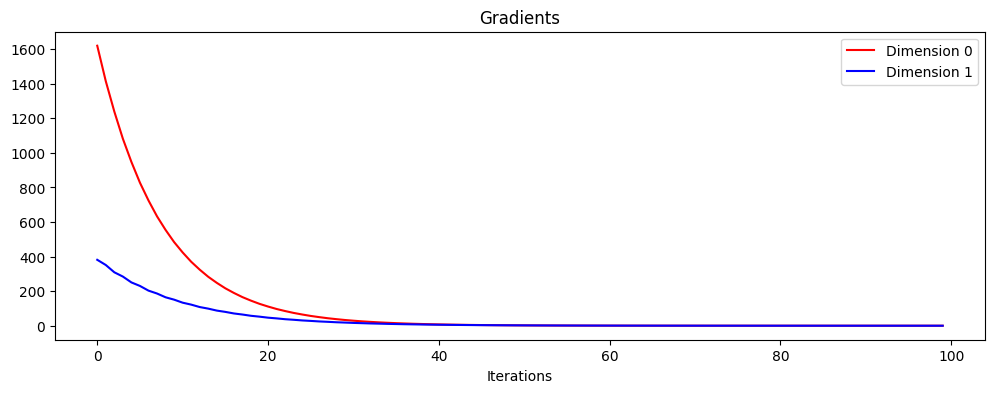

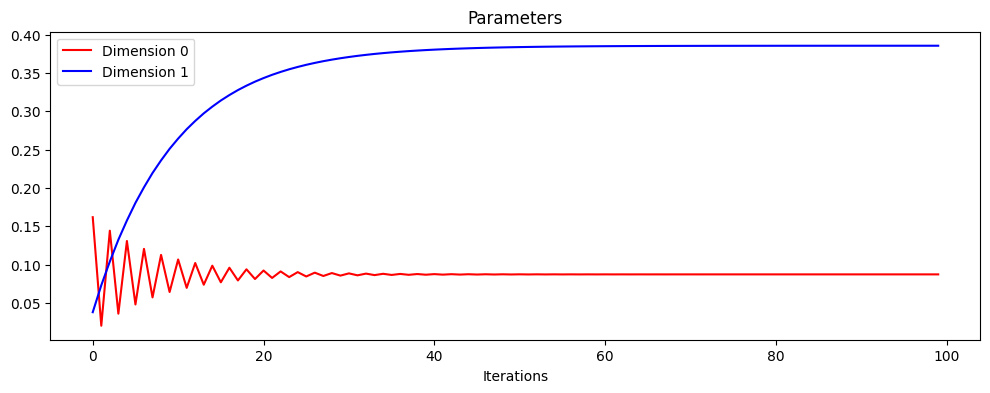

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(range(maxiter), np.abs(grads)[:,0], 'r', label="Dimension 0")
plt.plot(range(maxiter), np.abs(grads)[:,1], 'b', label="Dimension 1")
plt.title("Gradients")
plt.xlabel("Iterations")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(range(maxiter), np.abs(ws)[:,0], 'r', label="Dimension 0")
plt.plot(range(maxiter), np.abs(ws)[:,1], 'b', label="Dimension 1")
plt.title("Parameters")
plt.xlabel("Iterations")
plt.legend()
plt.show()

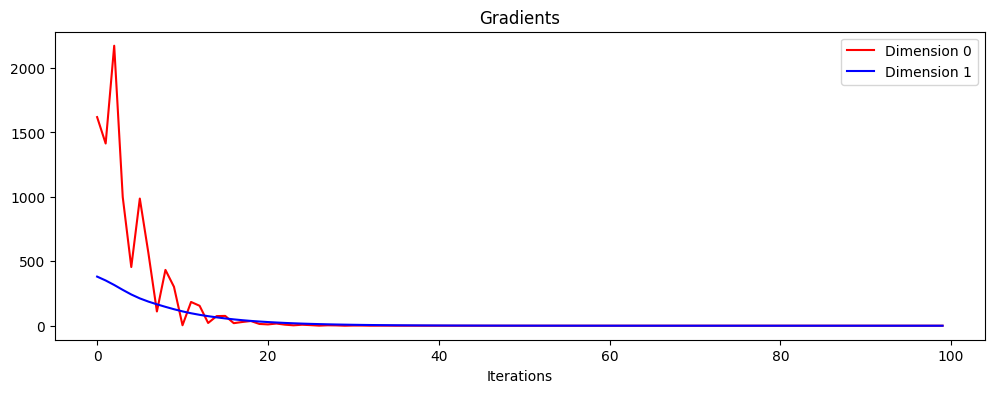

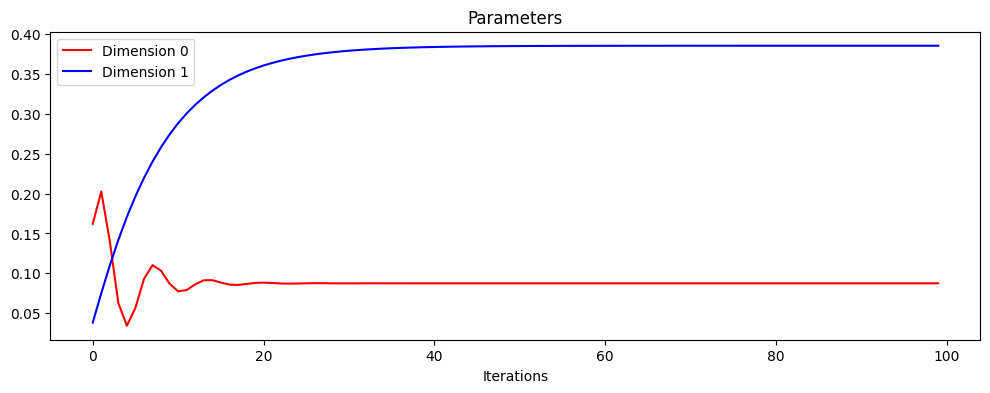

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(range(maxiter), np.abs(grads_m)[:,0], 'r', label="Dimension 0")
plt.plot(range(maxiter), np.abs(grads_m)[:,1], 'b', label="Dimension 1")
plt.title("Gradients")
plt.xlabel("Iterations")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(range(maxiter), np.abs(ws_m)[:,0], 'r', label="Dimension 0")
plt.plot(range(maxiter), np.abs(ws_m)[:,1], 'b', label="Dimension 1")
plt.title("Parameters")
plt.xlabel("Iterations")
plt.legend()
plt.show()

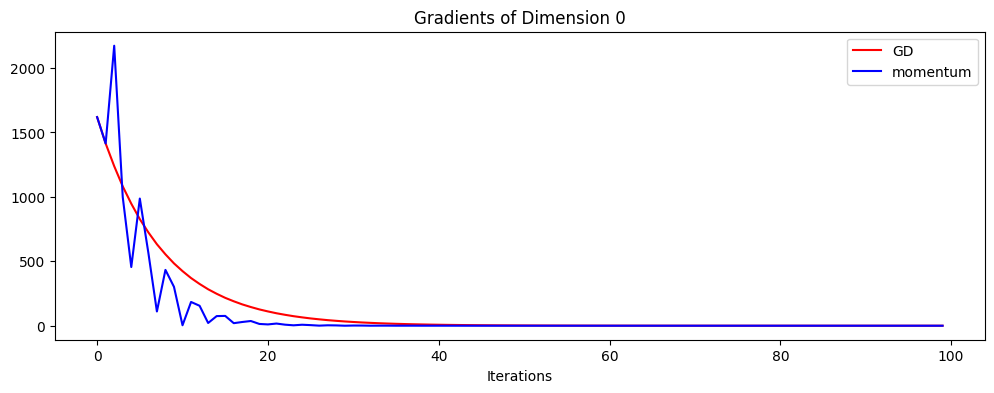

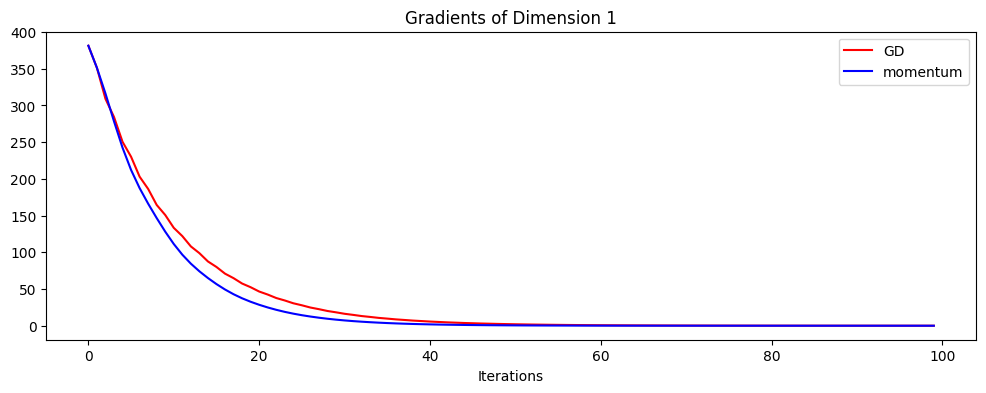

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(range(maxiter), np.abs(grads)[:,0], 'r', label="GD")
plt.plot(range(maxiter), np.abs(grads_m)[:,0], 'b', label="momentum")
plt.title("Gradients of Dimension 0")
plt.xlabel("Iterations")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(range(maxiter), np.abs(grads)[:,1], 'r', label="GD")
plt.plot(range(maxiter), np.abs(grads_m)[:,1], 'b', label="momentum")
plt.title("Gradients of Dimension 1")
plt.xlabel("Iterations")
plt.legend()
plt.show()

/tmp/ipython-input-12-1636177799.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot(range(maxiter), np.log(np.abs(losses)-losses[-1]), 'r', label="GD")
/tmp/ipython-input-12-1636177799.py:3: RuntimeWarning: divide by zero encountered in log
  plt.plot(range(maxiter), np.log(np.abs(losses_m)-losses_m[-1]), 'b', label="momentum")


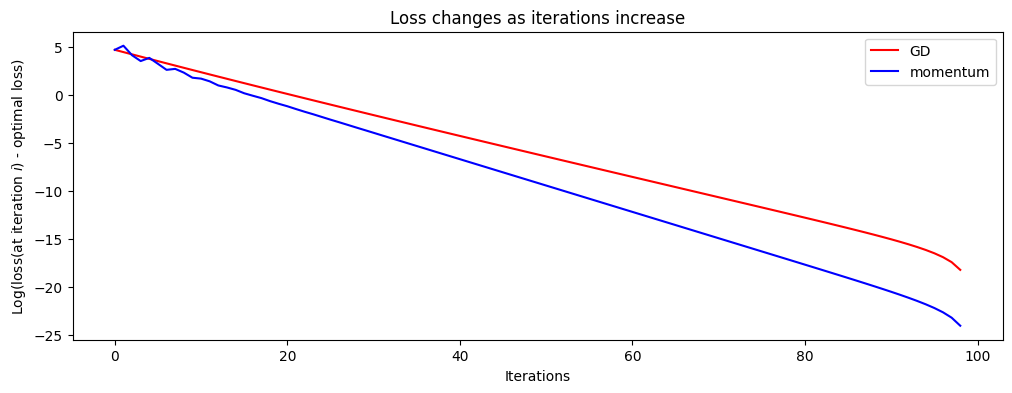

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(range(maxiter), np.log(np.abs(losses)-losses[-1]), 'r', label="GD")
plt.plot(range(maxiter), np.log(np.abs(losses_m)-losses_m[-1]), 'b', label="momentum")
plt.title("Loss changes as iterations increase")
plt.legend()
plt.ylabel("Log(loss(at iteration $i$) - optimal loss)")
plt.xlabel("Iterations")
plt.show()

In [ ]:
import numpy as np

"""
This file implements various first-order update rules that are commonly used for
training neural networks. Each update rule accepts current weights and the
gradient of the loss with respect to those weights and produces the next set of
weights. Each update rule has the same interface:

def update(w, dw, config=None):

Inputs:
  - w: A numpy array giving the current weights.
  - dw: A numpy array of the same shape as w giving the gradient of the
    loss with respect to w.
  - config: A dictionary containing hyperparameter values such as learning rate,
    momentum, etc. If the update rule requires caching values over many
    iterations, then config will also hold these cached values.

Returns:
  - next_w: The next point after the update.
  - config: The config dictionary to be passed to the next iteration of the
    update rule.

NOTE: For most update rules, the default learning rate will probably not perform
well; however the default values of the other hyperparameters should work well
for a variety of different problems.

For efficiency, update rules may perform in-place updates, mutating w and
setting next_w equal to w.
"""


def sgd(w, dw, config=None):
    """
    Performs vanilla stochastic gradient descent.

    config format:
    - learning_rate: Scalar learning rate.
    """
    if config is None:
        config = {}
    config.setdefault("learning_rate", 1e-2)

    w -= config["learning_rate"] * dw
    return w, config


def sgd_momentum(w, dw, config=None):
    """
    Performs stochastic gradient descent with momentum.

    config format:
    - learning_rate: Scalar learning rate.
    - momentum: Scalar between 0 and 1 giving the momentum value.
      Setting momentum = 0 reduces to sgd.
    - velocity: A numpy array of the same shape as w and dw used to store a moving
      average of the gradients.
    """
    if config is None:
        config = {}
    config.setdefault("learning_rate", 1e-2)
    config.setdefault("momentum", 0.9)
    v = config.get("velocity", np.zeros_like(w))

    v = config["momentum"] * v - config["learning_rate"] * dw
    next_w = w + v
    config["velocity"] = v

    return next_w, config


def rmsprop(w, dw, config=None):
    """
    Uses the RMSProp update rule, which uses a moving average of squared gradient
    values to set adaptive per-parameter learning rates.

    config format:
    - learning_rate: Scalar learning rate.
    - decay_rate: Scalar between 0 and 1 giving the decay rate for the squared
      gradient cache.
    - epsilon: Small scalar used for smoothing to avoid dividing by zero.
    - cache: Moving average of second moments of gradients.
    """
    if config is None:
        config = {}
    config.setdefault("learning_rate", 1e-2)
    config.setdefault("decay_rate", 0.99)
    config.setdefault("epsilon", 1e-8)
    config.setdefault("cache", np.zeros_like(w))

    cache = config["cache"]
    cache = config["decay_rate"] * cache + (1 - config["decay_rate"]) * (dw ** 2)
    next_w = w - config["learning_rate"] * dw / (np.sqrt(cache) + config["epsilon"])
    config["cache"] = cache

    return next_w, config


def adam(w, dw, config=None):
    """
    Uses the Adam update rule, which incorporates moving averages of both the
    gradient and its square and a bias correction term.

    config format:
    - learning_rate: Scalar learning rate.
    - beta1: Decay rate for moving average of first moment of gradient.
    - beta2: Decay rate for moving average of second moment of gradient.
    - epsilon: Small scalar used for smoothing to avoid dividing by zero.
    - m: Moving average of gradient.
    - v: Moving average of squared gradient.
    - t: Iteration number.
    """
    if config is None:
        config = {}
    config.setdefault("learning_rate", 1e-3)
    config.setdefault("beta1", 0.9)
    config.setdefault("beta2", 0.999)
    config.setdefault("epsilon", 1e-8)
    config.setdefault("m", np.zeros_like(w))
    config.setdefault("v", np.zeros_like(w))
    config.setdefault("t", 0)

    m = config["m"]
    v = config["v"]
    t = config["t"] + 1

    m = config["beta1"] * m + (1 - config["beta1"]) * dw
    v = config["beta2"] * v + (1 - config["beta2"]) * (dw ** 2)

    m_hat = m / (1 - config["beta1"] ** t)
    v_hat = v / (1 - config["beta2"] ** t)

    next_w = w - config["learning_rate"] * m_hat / (np.sqrt(v_hat) + config["epsilon"])

    config["m"] = m
    config["v"] = v
    config["t"] = t

    return next_w, config


In [ ]:
num_train = 4000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

solvers = {}

for update_rule in ['sgd', 'sgd_momentum']:
    print ('running with ', update_rule)
    model = FullyConnectedNet([100, 100, 100, 100, 100], weight_scale=5e-2)
num_train = 4000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

solvers = {}

for update_rule in ['sgd', 'sgd_momentum']:
    print ('running with ', update_rule)
    model = FullyConnectedNet([100, 100, 100, 100, 100], weight_scale=5e-2)

    solver = Solver(model, small_data,
                  num_epochs=5, batch_size=100,
                  update_rule=update_rule,
                  optim_config={
                    'learning_rate': 1e-2,
                  },
                  verbose=True)
    solvers[update_rule] = solver
    solver.train()
    os.makedirs("submission_logs", exist_ok=True)
    solver.record_histories_as_npz("submission_logs/optimizer_experiment_{}".format(update_rule))
    print

plt.subplot(3, 1, 1)
plt.title('Training loss')
plt.xlabel('Iteration')

plt.subplot(3, 1, 2)
plt.title('Training accuracy')
plt.xlabel('Epoch')

plt.subplot(3, 1, 3)
plt.title('Validation accuracy')
plt.xlabel('Epoch')

for update_rule, solver in solvers.items():
    plt.subplot(3, 1, 1)
    plt.plot(solver.loss_history, 'o', label=update_rule)

    plt.subplot(3, 1, 2)
    plt.plot(solver.train_acc_history, '-o', label=update_rule)

    plt.subplot(3, 1, 3)
    plt.plot(solver.val_acc_history, '-o', label=update_rule)

for i in [1, 2, 3]:
    plt.subplot(3, 1, i)
    plt.legend(loc='upper center', ncol=4)
plt.gcf().set_size_inches(15, 15)
plt.show()
    solver = Solver(model, small_data,
                  num_epochs=5, batch_size=100,
                  update_rule=update_rule,
                  optim_config={
                    'learning_rate': 1e-2,
                  },
                  verbose=True)
    solvers[update_rule] = solver
    solver.train()
    os.makedirs("submission_logs", exist_ok=True)
    solver.record_histories_as_npz("submission_logs/optimizer_experiment_{}".format(update_rule))
    print

plt.subplot(3, 1, 1)
plt.title('Training loss')
plt.xlabel('Iteration')

plt.subplot(3, 1, 2)
plt.title('Training accuracy')
plt.xlabel('Epoch')

plt.subplot(3, 1, 3)
plt.title('Validation accuracy')
plt.xlabel('Epoch')

for update_rule, solver in solvers.items():
    plt.subplot(3, 1, 1)
    plt.plot(solver.loss_history, 'o', label=update_rule)

    plt.subplot(3, 1, 2)
    plt.plot(solver.train_acc_history, '-o', label=update_rule)

    plt.subplot(3, 1, 3)
    plt.plot(solver.val_acc_history, '-o', label=update_rule)

for i in [1, 2, 3]:
    plt.subplot(3, 1, i)
    plt.legend(loc='upper center', ncol=4)
plt.gcf().set_size_inches(15, 15)
plt.show()

NameError: name 'data' is not defined

In [ ]:
import torch
import torch.nn as nn

class FullyConnectedNet(nn.Module):
    def __init__(self, hidden_dims, input_dim=3*32*32, num_classes=10, weight_scale=5e-2):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            l = nn.Linear(in_dim, h)
            nn.init.normal_(l.weight, 0.0, weight_scale)
            nn.init.zeros_(l.bias)
            layers += [l, nn.ReLU(inplace=True)]
            in_dim = h
        l = nn.Linear(in_dim, num_classes)
        nn.init.normal_(l.weight, 0.0, weight_scale)
        nn.init.zeros_(l.bias)
        layers.append(l)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)


In [ ]:
import numpy as np




class Solver(object):
    """
    A Solver encapsulates all the logic necessary for training classification
    models. The Solver performs stochastic gradient descent using different
    update rules defined in optim.py.

    The solver accepts both training and validataion data and labels so it can
    periodically check classification accuracy on both training and validation
    data to watch out for overfitting.

    To train a model, you will first construct a Solver instance, passing the
    model, dataset, and various optoins (learning rate, batch size, etc) to the
    constructor. You will then call the train() method to run the optimization
    procedure and train the model.

    After the train() method returns, model.params will contain the parameters
    that performed best on the validation set over the course of training.
    In addition, the instance variable solver.loss_history will contain a list
    of all losses encountered during training and the instance variables
    solver.train_acc_history and solver.val_acc_history will be lists containing
    the accuracies of the model on the training and validation set at each epoch.

    Example usage might look something like this:

    data = {
      'X_train': # training data
      'y_train': # training labels
      'X_val': # validation data
      'X_train': # validation labels
    }
    model = MyAwesomeModel(hidden_size=100, reg=10)
    solver = Solver(model, data,
                    update_rule='sgd',
                    optim_config={
                      'learning_rate': 1e-3,
                    },
                    lr_decay=0.95,
                    num_epochs=10, batch_size=100,
                    print_every=100)
    solver.train()


    A Solver works on a model object that must conform to the following API:

    - model.params must be a dictionary mapping string parameter names to numpy
      arrays containing parameter values.

    - model.loss(X, y) must be a function that computes training-time loss and
      gradients, and test-time classification scores, with the following inputs
      and outputs:

      Inputs:
      - X: Array giving a minibatch of input data of shape (N, d_1, ..., d_k)
      - y: Array of labels, of shape (N,) giving labels for X where y[i] is the
        label for X[i].

      Returns:
      If y is None, run a test-time forward pass and return:
      - scores: Array of shape (N, C) giving classification scores for X where
        scores[i, c] gives the score of class c for X[i].

      If y is not None, run a training time forward and backward pass and return
      a tuple of:
      - loss: Scalar giving the loss
      - grads: Dictionary with the same keys as self.params mapping parameter
        names to gradients of the loss with respect to those parameters.
    """

    def __init__(self, model, data, **kwargs):
        """
        Construct a new Solver instance.

        Required arguments:
        - model: A model object conforming to the API described above
        - data: A dictionary of training and validation data with the following:
          'X_train': Array of shape (N_train, d_1, ..., d_k) giving training images
          'X_val': Array of shape (N_val, d_1, ..., d_k) giving validation images
          'y_train': Array of shape (N_train,) giving labels for training images
          'y_val': Array of shape (N_val,) giving labels for validation images

        Optional arguments:
        - update_rule: A string giving the name of an update rule in optim.py.
          Default is 'sgd'.
        - optim_config: A dictionary containing hyperparameters that will be
          passed to the chosen update rule. Each update rule requires different
          hyperparameters (see optim.py) but all update rules require a
          'learning_rate' parameter so that should always be present.
        - lr_decay: A scalar for learning rate decay; after each epoch the learning
          rate is multiplied by this value.
        - batch_size: Size of minibatches used to compute loss and gradient during
          training.
        - num_epochs: The number of epochs to run for during training.
        - print_every: Integer; training losses will be printed every print_every
          iterations.
        - verbose: Boolean; if set to false then no output will be printed during
          training.
        """
        self.model = model
        self.X_train = data["X_train"]
        self.y_train = data["y_train"]
        self.X_val = data["X_val"]
        self.y_val = data["y_val"]

        # Unpack keyword arguments
        self.update_rule = kwargs.pop("update_rule", "sgd")
        self.optim_config = kwargs.pop("optim_config", {})
        self.lr_decay = kwargs.pop("lr_decay", 1.0)
        self.batch_size = kwargs.pop("batch_size", 100)
        self.num_epochs = kwargs.pop("num_epochs", 10)

        self.print_every = kwargs.pop("print_every", 10)
        self.verbose = kwargs.pop("verbose", True)
        self.log_acc_iteration = kwargs.pop("log_acc_iteration", False)

        # Throw an error if there are extra keyword arguments
        if len(kwargs) > 0:
            extra = ", ".join('"%s"' % k for k in kwargs.keys())
            raise ValueError("Unrecognized arguments %s" % extra)

        # Make sure the update rule exists, then replace the string
        # name with the actual function
        if not hasattr(optim, self.update_rule):
            raise ValueError('Invalid update_rule "%s"' % self.update_rule)
        self.update_rule = getattr(optim, self.update_rule)

        self._reset()

    def _reset(self):
        """
        Set up some book-keeping variables for optimization. Don't call this
        manually.
        """
        # Set up some variables for book-keeping
        self.epoch = 0
        self.best_val_acc = 0
        self.best_params = {}
        self.loss_history = []
        self.train_acc_history = []
        self.val_acc_history = []
        self.log_acc_iteration_history = []
        self.log_grad_norm_history = []

        # Make a deep copy of the optim_config for each parameter
        self.optim_configs = {}
        for p in self.model.params:
            d = {k: v for k, v in self.optim_config.items()}
            self.optim_configs[p] = d

    def _step(self):
        num_train = self.X_train.shape[0]
        batch_mask = np.random.choice(num_train, self.batch_size)
        X_batch = self.X_train[batch_mask]
        y_batch = self.y_train[batch_mask]

        loss, grads = self.model.loss(X_batch, y_batch)
        self.loss_history.append(loss)

        grad_norms = []
        for p, w in self.model.params.items():
            dw = grads[p]
            grad_norms.append(np.linalg.norm(dw))
            config = self.optim_configs[p]
            next_w, next_config = self.update_rule(w, dw, config)
            self.model.params[p] = next_w
            self.optim_configs[p] = next_config

        self.log_grad_norm_history.append(np.mean(grad_norms))


    def record_histories_as_npz(self, filename):
        tl_hist = np.array(self.loss_history)
        ta_hist = np.array(self.train_acc_history)
        va_hist = np.array(self.val_acc_history)
        np.savez(filename, train_losses=tl_hist, train_accs=ta_hist, val_accs=va_hist)

    def check_accuracy(self, X, y, num_samples=None, batch_size=100):
        """
        Check accuracy of the model on the provided data.

        Inputs:
        - X: Array of data, of shape (N, d_1, ..., d_k)
        - y: Array of labels, of shape (N,)
        - num_samples: If not None, subsample the data and only test the model
          on num_samples datapoints.
        - batch_size: Split X and y into batches of this size to avoid using too
          much memory.

        Returns:
        - acc: Scalar giving the fraction of instances that were correctly
          classified by the model.
        """

        # Maybe subsample the data
        N = X.shape[0]
        if num_samples is not None and N > num_samples:
            mask = np.random.choice(N, num_samples)
            N = num_samples
            X = X[mask]
            y = y[mask]

        # Compute predictions in batches
        num_batches = N // batch_size
        if N % batch_size != 0:
            num_batches += 1
        y_pred = []
        for i in range(num_batches):
            start = i * batch_size
            end = (i + 1) * batch_size
            scores = self.model.loss(X[start:end])
            y_pred.append(np.argmax(scores, axis=1))
        y_pred = np.hstack(y_pred)
        acc = np.mean(y_pred == y)

        return acc

    def train(self):
        """
        Run optimization to train the model.
        """
        num_train = self.X_train.shape[0]
        iterations_per_epoch = max(num_train // self.batch_size, 1)
        num_iterations = self.num_epochs * iterations_per_epoch

        for t in range(num_iterations):
            self._step()

            # Maybe print training loss
            if self.verbose and t % self.print_every == 0:
                print(
                    "(Iteration %d / %d) loss: %f"
                    % (t + 1, num_iterations, self.loss_history[-1])
                )

            # At the end of every epoch, increment the epoch counter and decay the
            # learning rate.
            epoch_end = (t + 1) % iterations_per_epoch == 0
            if epoch_end:
                self.epoch += 1
                for k in self.optim_configs:
                    self.optim_configs[k]["learning_rate"] *= self.lr_decay

            # Check train and val accuracy on the first iteration, the last
            # iteration, and at the end of each epoch.
            first_it = t == 0
            last_it = t == num_iterations + 1
            if first_it or last_it or epoch_end:
                train_acc = self.check_accuracy(
                    self.X_train, self.y_train, num_samples=1000
                )
                val_acc = self.check_accuracy(self.X_val, self.y_val)
                if self.log_acc_iteration:
                    self.log_acc_iteration_history.append(t)
                self.train_acc_history.append(train_acc)
                self.val_acc_history.append(val_acc)

                if self.verbose:
                    print(
                        "(Epoch %d / %d) train acc: %f; val_acc: %f"
                        % (self.epoch, self.num_epochs, train_acc, val_acc)
                    )

                # Keep track of the best model
                if val_acc > self.best_val_acc:
                    self.best_val_acc = val_acc
                    self.best_params = {}
                    for k, v in self.model.params.items():
                        self.best_params[k] = v.copy()

        # At the end of training swap the best params into the model
        self.model.params = self.best_params


In [ ]:
from math import sqrt, ceil

import numpy as np


def visualize_grid(Xs, ubound=255.0, padding=1):
    """
    Reshape a 4D tensor of image data to a grid for easy visualization.

    Inputs:
    - Xs: Data of shape (N, H, W, C)
    - ubound: Output grid will have values scaled to the range [0, ubound]
    - padding: The number of blank pixels between elements of the grid
    """
    (N, H, W, C) = Xs.shape
    grid_size = int(ceil(sqrt(N)))
    grid_height = H * grid_size + padding * (grid_size - 1)
    grid_width = W * grid_size + padding * (grid_size - 1)
    grid = np.zeros((grid_height, grid_width, C))
    next_idx = 0
    y0, y1 = 0, H
    for y in range(grid_size):
        x0, x1 = 0, W
        for x in range(grid_size):
            if next_idx < N:
                img = Xs[next_idx]
                low, high = np.min(img), np.max(img)
                grid[y0:y1, x0:x1] = ubound * (img - low) / (high - low)
                # grid[y0:y1, x0:x1] = Xs[next_idx]
                next_idx += 1
            x0 += W + padding
            x1 += W + padding
        y0 += H + padding
        y1 += H + padding
    # grid_max = np.max(grid)
    # grid_min = np.min(grid)
    # grid = ubound * (grid - grid_min) / (grid_max - grid_min)
    return grid


def vis_grid(Xs):
    """ visualize a grid of images """
    (N, H, W, C) = Xs.shape
    A = int(ceil(sqrt(N)))
    G = np.ones((A * H + A, A * W + A, C), Xs.dtype)
    G *= np.min(Xs)
    n = 0
    for y in range(A):
        for x in range(A):
            if n < N:
                G[y * H + y:(y + 1) * H + y, x * W + x:(x + 1) * W + x, :] = Xs[n, :, :, :]
                n += 1
    # normalize to [0,1]
    maxg = G.max()
    ming = G.min()
    G = (G - ming) / (maxg - ming)
    return G


def vis_nn(rows):
    """ visualize array of arrays of images """
    N = len(rows)
    D = len(rows[0])
    H, W, C = rows[0][0].shape
    Xs = rows[0][0]
    G = np.ones((N * H + N, D * W + D, C), Xs.dtype)
    for y in range(N):
        for x in range(D):
            G[y * H + y:(y + 1) * H + y, x * W + x:(x + 1) * W + x, :] = rows[y][x]
    # normalize to [0,1]
    maxg = G.max()
    ming = G.min()
    G = (G - ming) / (maxg - ming)
    return G


In [ ]:
import torch
import torch.nn as nn
import functools
width = 20

model = nn.Sequential(
    nn.Linear(1, width),
    nn.ReLU(),
    nn.Linear(width, width),
    nn.ReLU(),
    nn.Linear(width, width),
    nn.ReLU(),
    nn.Linear(width, width),
    nn.ReLU(),
    nn.Linear(width, 1)
)

assert len(model) == 9
assert sum(p.numel() for p in model.parameters()) == 1321
assert list(model(torch.randn(10, 1)).shape) == [10, 1]
# Initialize the neural network

def naive_init(scale, module):
    if isinstance(module, nn.Linear):
        nn.init.uniform_(module.weight, -scale, scale)
        nn.init.zeros_(module.bias)


np.random.seed(200)
torch.manual_seed(200)
model.apply(functools.partial(naive_init, 0.03))


Sequential(
  (0): Linear(in_features=1, out_features=20, bias=True)
  (1): ReLU()
  (2): Linear(in_features=20, out_features=20, bias=True)
  (3): ReLU()
  (4): Linear(in_features=20, out_features=20, bias=True)
  (5): ReLU()
  (6): Linear(in_features=20, out_features=20, bias=True)
  (7): ReLU()
  (8): Linear(in_features=20, out_features=1, bias=True)
)

In [ ]:
def print_gnorms(model):
    batch_x = torch.from_numpy(train_x).float().unsqueeze(-1)
    batch_y = torch.from_numpy(train_y).float()
    pred = model(batch_x).view(-1)
    criterion = nn.MSELoss()
    loss = criterion(batch_y, pred)
    model.zero_grad()
    loss.backward()

    for name, param in model.named_parameters():
        if name.endswith(".weight"):
            with torch.no_grad():
                gnorm = param.grad.norm().item()
                print(name, "{:.8f}".format(gnorm))


In [ ]:
m, singular_values, principal_feature = svd_local_linearization(model)
visualize(m, singular_values, principal_feature)

NameError: name 'svd_local_linearization' is not defined